# Breast Cancer Survival Classification

Predict death from any cause in SEER breast cancer patients (4,024 rows) from features known at diagnosis. Survival Months is excluded because follow-up length depends on the outcome; all other features are known at diagnosis.

Protocol:
- Stratified 80/20 train/test split (`random_state=42`).
- Every choice (features, model, hyperparameters, resampling, threshold) is made with **5x5 repeated stratified CV on the training set only**.
- Encoding, feature engineering, scaling, resampling and threshold tuning sit inside the pipeline that CV refits on each fold. The decision threshold is tuned by an inner 5-fold CV inside each outer training fold (`TunedThresholdClassifierCV`), so the CV F1 is out-of-sample.
- The test set is used once, in the last section, for the chosen pipeline and the one-hot reference model. Bootstrap 95 % CIs.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_validate, TunedThresholdClassifierCV)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, FunctionTransformer,
                                   SplineTransformer, PolynomialFeatures)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier
from sklearn.calibration import calibration_curve
from sklearn.base import clone
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, recall_score,
                             precision_score, make_scorer)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

SEED = 42
# Dataset (SEER breast cancer, public copy):
# https://github.com/WEEDUENHEH/Breast-cancer-dataset/raw/9c577ad0fb9e3b5e269b7f12ba86d39a87e6180c/Breast_Cancer_dataset_.xlsx
df = pd.read_excel('data.xlsx')
df.columns = df.columns.str.strip()
for c in df.columns:
    if not pd.api.types.is_numeric_dtype(df[c]):
        df[c] = df[c].astype(str).str.strip().str.lower()
y = (df['Status'] == 'dead').astype(int)
X = df.drop(columns=['Status', 'Survival Months'])      # follow-up length depends on the outcome
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
print(df.shape, '| train', len(X_train), f'({y_train.sum()} dead) | test', len(X_test), f'({y_test.sum()} dead)')

(4024, 16) | train 3219 (493 dead) | test 805 (123 dead)


## Feature check: known at diagnosis?

| Column | Known at diagnosis? | Keep |
|---|---|---|
| Survival Months | No: follow-up length, shorter for patients who died | **Dropped** |
| Age, Race | Yes | Yes |
| Marital Status | Yes, recorded at diagnosis in SEER | Yes |
| T, N, 6th Stage, A Stage | Yes, AJCC staging at diagnosis | Yes |
| differentiate, Grade | Yes, pathology at diagnosis. **The two columns are the same variable** (crosstab below), so only one is used | One |
| Tumor Size | Yes | Yes |
| Estrogen / Progesterone Status | Yes, receptor status at diagnosis | Yes |
| Regional Node Examined / Positive | Yes, surgical pathology at diagnosis | Yes |

All kept columns are known at diagnosis. Data checks: positive nodes never exceed examined nodes, and at least one node is always examined, so the node ratio is always defined. T stage is essentially a tumour-size bin (T1 up to 20 mm, T2 20 to 50 mm, T3 above 50 mm), so separate size bins would duplicate it; log tumour size is used instead.

In [2]:
print(pd.crosstab(df['Grade'], df['differentiate']))
print('positive > examined:', (df['Reginol Node Positive'] > df['Regional Node Examined']).sum(),
      '| min examined:', df['Regional Node Examined'].min())
print(pd.crosstab(df['T Stage'], pd.cut(df['Tumor Size'], [0, 20, 50, 200])))

differentiate         moderately differentiated  poorly differentiated  \
Grade                                                                    
1                                             0                      0   
2                                          2351                      0   
3                                             0                   1111   
anaplastic; grade iv                          0                      0   

differentiate         undifferentiated  well differentiated  
Grade                                                        
1                                    0                  543  
2                                    0                    0  
3                                    0                    0  
anaplastic; grade iv                19                    0  
positive > examined: 0 | min examined: 1
Tumor Size  (0, 20]  (20, 50]  (50, 200]
T Stage                                 
t1             1603         0          0
t2                0

## Feature sets

- **one-hot** (the reference): 4 numerics scaled, 10 categoricals one-hot.
- **engineered**: ordinal T (1-4), N (1-3), 6th stage (1-5) and grade (1-4); binary ER, PR, distant A stage; log tumour size; log positive nodes; nodes examined; **node ratio** (positive / examined); race and marital status one-hot. The transformation is row-wise (no fitted state), and it still sits inside the pipeline.

In [3]:
T_MAP = {'t1': 1, 't2': 2, 't3': 3, 't4': 4}
N_MAP = {'n1': 1, 'n2': 2, 'n3': 3}
S_MAP = {'iia': 1, 'iib': 2, 'iiia': 3, 'iiib': 4, 'iiic': 5}
G_MAP = {'well differentiated': 1, 'moderately differentiated': 2, 'poorly differentiated': 3, 'undifferentiated': 4}

def engineer(d):
    pos, exam = d['Reginol Node Positive'], d['Regional Node Examined']
    return pd.DataFrame({
        'age': d['Age'], 't_stage': d['T Stage'].map(T_MAP), 'n_stage': d['N Stage'].map(N_MAP),
        'stage6': d['6th Stage'].map(S_MAP), 'grade': d['differentiate'].map(G_MAP),
        'distant': (d['A Stage'] == 'distant').astype(int),
        'er_pos': (d['Estrogen Status'] == 'positive').astype(int),
        'pr_pos': (d['Progesterone Status'] == 'positive').astype(int),
        'log_tumor': np.log1p(d['Tumor Size']), 'log_nodes_pos': np.log1p(pos),
        'nodes_exam': exam, 'node_ratio': pos / exam,
        'race': d['Race'], 'marital': d['Marital Status']}, index=d.index)

FE_NUM = ['age', 't_stage', 'n_stage', 'stage6', 'grade', 'distant', 'er_pos', 'pr_pos',
          'log_tumor', 'log_nodes_pos', 'nodes_exam', 'node_ratio']
FE_CAT = ['race', 'marital']
SPLINE = ['age', 'log_tumor', 'log_nodes_pos', 'node_ratio']
OH_NUM = ['Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive']
OH_CAT = ['Race', 'Marital Status', 'T Stage', 'N Stage', '6th Stage', 'differentiate',
          'Grade', 'A Stage', 'Estrogen Status', 'Progesterone Status']
FE = ('fe', FunctionTransformer(engineer))
ohe = lambda: OneHotEncoder(handle_unknown='ignore', sparse_output=False)

def prep_onehot():
    return ColumnTransformer([('num', StandardScaler(), OH_NUM), ('cat', ohe(), OH_CAT)])
def prep_fe(splines=False, interactions=False):
    num = [n for n in FE_NUM if not (splines and n in SPLINE)]
    numpipe = Pipeline([('sc', StandardScaler())] +
                       ([('ix', PolynomialFeatures(2, interaction_only=True, include_bias=False))] if interactions else []))
    parts = [('num', numpipe, num), ('cat', ohe(), FE_CAT)]
    if splines:
        parts.append(('spl', SplineTransformer(n_knots=4, degree=3), SPLINE))
    return ColumnTransformer(parts)

def lr(C=1.0, cw=None):
    return LogisticRegression(C=C, class_weight=cw, max_iter=5000)
def hgb(max_iter=200, depth=3, lr_=0.05, cw=None):
    return HistGradientBoostingClassifier(max_iter=max_iter, max_depth=depth, learning_rate=lr_,
                                          min_samples_leaf=40, l2_regularization=1.0, class_weight=cw, random_state=SEED)
def lgbm(n=200, leaves=7):
    return LGBMClassifier(n_estimators=n, num_leaves=leaves, learning_rate=0.03, min_child_samples=40,
                          subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
                          random_state=SEED, n_jobs=1, verbose=-1)

## Candidates, each scored with 5x5 repeated stratified CV

Each pipeline is wrapped in `TunedThresholdClassifierCV(scoring='f1')`: inside every outer training fold an inner 5-fold CV picks the F1-maximising threshold, so F1, recall and precision below are out-of-sample numbers. ROC AUC, PR AUC and Brier score do not depend on the threshold. Brier is lower-is-better and measures calibration plus discrimination.

In [4]:
def P(*steps): return Pipeline(list(steps))
cands = {
 'A  Reference: logistic regression, one-hot':    P(('prep', prep_onehot()), ('clf', lr(1.0, 'balanced'))),
 'B1 LR engineered, C=0.01':                   P(FE, ('prep', prep_fe()), ('clf', lr(0.01))),
 'B2 LR engineered, C=0.1':                    P(FE, ('prep', prep_fe()), ('clf', lr(0.1))),
 'B3 LR engineered, C=1':                      P(FE, ('prep', prep_fe()), ('clf', lr(1.0))),
 'C  LR engineered, C=0.1, balanced':          P(FE, ('prep', prep_fe()), ('clf', lr(0.1, 'balanced'))),
 'D  LR engineered, C=0.1, SMOTE':             P(FE, ('prep', prep_fe()), ('smote', SMOTE(random_state=SEED)), ('clf', lr(0.1))),
 'E  LR engineered + splines, C=0.1':          P(FE, ('prep', prep_fe(splines=True)), ('clf', lr(0.1))),
 'F  LR engineered + interactions, C=0.01':    P(FE, ('prep', prep_fe(interactions=True)), ('clf', lr(0.01))),
 'G1 HGB depth 2, 200 iter':                   P(FE, ('prep', prep_fe()), ('clf', hgb(200, 2))),
 'G2 HGB depth 3, 100 iter':                   P(FE, ('prep', prep_fe()), ('clf', hgb(100, 3))),
 'G3 HGB depth 3, 300 iter':                   P(FE, ('prep', prep_fe()), ('clf', hgb(300, 3))),
 'G4 HGB depth 2, 200 iter, balanced':         P(FE, ('prep', prep_fe()), ('clf', hgb(200, 2, cw='balanced'))),
 'H1 LightGBM 7 leaves, 200 trees':            P(FE, ('prep', prep_fe()), ('clf', lgbm(200, 7))),
 'H2 LightGBM 4 leaves, 300 trees':            P(FE, ('prep', prep_fe()), ('clf', lgbm(300, 4))),
}
cands['I  Average of B2 + G1'] = VotingClassifier(
    [('lr', cands['B2 LR engineered, C=0.1']), ('hgb', cands['G1 HGB depth 2, 200 iter'])], voting='soft')

outer = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)
inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'ROC AUC': 'roc_auc', 'PR AUC': 'average_precision', 'Brier': 'neg_brier_score',
           'F1': 'f1', 'recall': 'recall', 'precision': 'precision'}
cv_raw, rows = {}, []
for name, pipe in cands.items():
    t0 = time.time()
    r = cross_validate(TunedThresholdClassifierCV(pipe, scoring='f1', cv=inner), X_train, y_train,
                       cv=outer, scoring=scoring, n_jobs=10)
    cv_raw[name] = r
    row = {'candidate': name}
    for k in scoring:
        v = r['test_' + k] * (-1 if k == 'Brier' else 1)
        row[k] = f'{v.mean():.3f} ± {v.std():.3f}'
        row['_' + k] = v.mean()
    row['sec'] = round(time.time() - t0)
    rows.append(row)
cvtab = pd.DataFrame(rows).set_index('candidate')
cvtab[[c for c in cvtab.columns if not c.startswith('_')]]

,ROC AUC,PR AUC,Brier,F1,recall,precision,sec
candidate,,,,,,,
"A Reference: logistic regression, one-hot",0.740 ± 0.021,0.400 ± 0.022,0.200 ± 0.005,0.405 ± 0.022,0.565 ± 0.063,0.318 ± 0.019,5
"B1 LR engineered, C=0.01",0.743 ± 0.018,0.402 ± 0.024,0.113 ± 0.002,0.400 ± 0.023,0.483 ± 0.050,0.342 ± 0.021,3
"B2 LR engineered, C=0.1",0.744 ± 0.019,0.400 ± 0.025,0.113 ± 0.002,0.406 ± 0.026,0.521 ± 0.049,0.335 ± 0.027,3
"B3 LR engineered, C=1",0.743 ± 0.020,0.398 ± 0.024,0.113 ± 0.002,0.405 ± 0.026,0.528 ± 0.044,0.330 ± 0.027,3
"C LR engineered, C=0.1, balanced",0.743 ± 0.019,0.398 ± 0.024,0.200 ± 0.005,0.403 ± 0.022,0.525 ± 0.054,0.328 ± 0.020,3
"D LR engineered, C=0.1, SMOTE",0.738 ± 0.020,0.393 ± 0.024,0.200 ± 0.006,0.408 ± 0.028,0.524 ± 0.073,0.340 ± 0.032,3
"E LR engineered + splines, C=0.1",0.747 ± 0.019,0.401 ± 0.026,0.113 ± 0.002,0.404 ± 0.023,0.514 ± 0.065,0.338 ± 0.035,3
"F LR engineered + interactions, C=0.01",0.737 ± 0.018,0.401 ± 0.025,0.113 ± 0.002,0.405 ± 0.027,0.543 ± 0.059,0.326 ± 0.036,3
"G1 HGB depth 2, 200 iter",0.739 ± 0.021,0.389 ± 0.026,0.114 ± 0.002,0.405 ± 0.024,0.486 ± 0.057,0.352 ± 0.036,4


Mean ± std over the 25 outer folds. Hyperparameter grid points are listed as separate rows, so the reader sees the whole search; picking the best row of a small grid is mildly optimistic.

## Choosing the final pipeline (on CV only)

Rule, set before looking at the test set: take the best mean ROC AUC; among candidates within one standard error of it (std / √25), pick the simplest: plain logistic regression, then LR with splines or interactions, then boosting, then the ensemble. Explainability is a stated goal, so a gain smaller than fold noise does not buy complexity. Paired fold-wise differences against the reference show whether a gain is larger than fold noise.

In [5]:
auc = {n: cv_raw[n]['test_ROC AUC'] for n in cv_raw}
best = max(auc, key=lambda n: auc[n].mean())
se = auc[best].std() / np.sqrt(len(auc[best]))
within = [n for n in cv_raw if auc[n].mean() >= auc[best].mean() - se]
COMPLEXITY = {'A': 0, 'B': 0, 'C': 0, 'D': 0, 'E': 1, 'F': 1, 'G': 2, 'H': 2, 'I': 3}   # plain LR < LR+splines/interactions < boosting < ensemble
order = lambda n: (COMPLEXITY[n[0]], -auc[n].mean())
FINAL = sorted(within, key=order)[0]
print(f'best mean ROC AUC: {best} ({auc[best].mean():.3f}); 1-SE band >= {auc[best].mean() - se:.3f}')
print('within 1 SE:', within)
print('FINAL:', FINAL)
base = 'A  Reference: logistic regression, one-hot'
for k in ['ROC AUC', 'PR AUC', 'F1']:
    d = cv_raw[FINAL]['test_' + k] - cv_raw[base]['test_' + k]
    print(f'{k:8s} final - reference, paired over 25 folds: {d.mean():+.3f} ± {d.std():.3f}  (folds better: {(d > 0).sum()}/25)')

best mean ROC AUC: E  LR engineered + splines, C=0.1 (0.747); 1-SE band >= 0.743
within 1 SE: ['B2 LR engineered, C=0.1', 'C  LR engineered, C=0.1, balanced', 'E  LR engineered + splines, C=0.1', 'I  Average of B2 + G1']
FINAL: B2 LR engineered, C=0.1
ROC AUC  final - reference, paired over 25 folds: +0.003 ± 0.007  (folds better: 16/25)
PR AUC   final - reference, paired over 25 folds: -0.000 ± 0.013  (folds better: 14/25)
F1       final - reference, paired over 25 folds: +0.001 ± 0.017  (folds better: 13/25)


## Thresholds for the final pipeline, from out-of-fold probabilities on the training set

Two operating points, both picked on pooled out-of-fold probabilities (5 repeats of 5-fold CV): the F1-maximising threshold, and the highest threshold that keeps recall at or above 80 %. The calibration curve checks that the unweighted model's probabilities can be read as risks.

max F1       threshold 0.190: OOF F1 0.410±0.002  recall 0.544±0.004  precision 0.329±0.002
80 % recall  threshold 0.100: OOF F1 0.367±0.001  recall 0.808±0.003  precision 0.237±0.000


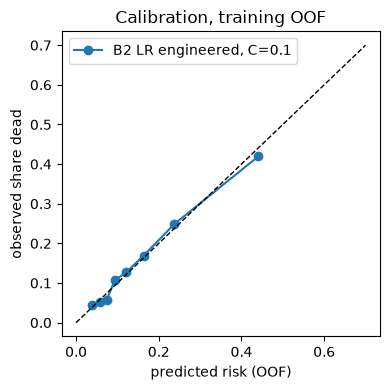

In [6]:
final_pipe = cands[FINAL]
oof = []
for rep in range(5):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + rep)
    p = np.zeros(len(y_train))
    for tr, va in skf.split(X_train, y_train):
        m = clone(final_pipe)
        m.fit(X_train.iloc[tr], y_train.iloc[tr]); p[va] = m.predict_proba(X_train.iloc[va])[:, 1]
    oof.append(p)
oof = np.array(oof); yy = np.tile(y_train.values, 5); pp = oof.ravel()
grid = np.round(np.arange(0.03, 0.80, 0.005), 3)
f1s = np.array([f1_score(yy, pp >= t) for t in grid])
T_F1 = grid[f1s.argmax()]
T_R80 = max(t for t in grid if recall_score(yy, pp >= t) >= 0.80)
for lab, t in [('max F1', T_F1), ('80 % recall', T_R80)]:
    per = [(f1_score(y_train, o >= t), recall_score(y_train, o >= t), precision_score(y_train, o >= t)) for o in oof]
    m_, s_ = np.mean(per, 0), np.std(per, 0)
    print(f'{lab:12s} threshold {t:.3f}: OOF F1 {m_[0]:.3f}±{s_[0]:.3f}  recall {m_[1]:.3f}±{s_[1]:.3f}  precision {m_[2]:.3f}±{s_[2]:.3f}')
fr, mp = calibration_curve(y_train, oof.mean(0), n_bins=8, strategy='quantile')
plt.figure(figsize=(4, 4)); plt.plot(mp, fr, 'o-', label=FINAL.split('  ')[0]); plt.plot([0, .7], [0, .7], 'k--', lw=1)
plt.xlabel('predicted risk (OOF)'); plt.ylabel('observed share dead'); plt.title('Calibration, training OOF'); plt.legend(); plt.tight_layout(); plt.show()

## What the final model says (coefficients, fitted on the full training set)

Standardised logistic-regression coefficients as odds ratios per one standard deviation (or per category vs the average). Shown only if the final pipeline is a logistic regression.

In [7]:
final_fit = clone(final_pipe).fit(X_train, y_train)
if hasattr(final_fit, 'named_steps') and isinstance(final_fit.named_steps['clf'], LogisticRegression):
    names = final_fit.named_steps['prep'].get_feature_names_out()
    coef = pd.Series(final_fit.named_steps['clf'].coef_[0], index=[n.split('__')[1] for n in names])
    out = pd.DataFrame({'coef': coef, 'odds ratio': np.exp(coef)}).sort_values('coef', key=abs, ascending=False)
    display(out.round(3).head(14))

,coef,odds ratio
marital_separated,0.355,1.426
grade,0.326,1.386
race_black,0.263,1.301
race_other,-0.258,0.773
node_ratio,0.247,1.280
t_stage,0.244,1.277
log_nodes_pos,0.224,1.252
marital_married,-0.222,0.801
er_pos,-0.201,0.818
pr_pos,-0.180,0.835


## Held-out test set: used once

The final pipeline (fitted on all 3,219 training rows, thresholds from the preceding section) and the reference model (A, refitted the same way, threshold 0.5) are scored on the 805 test rows. 95 % CIs from 2,000 bootstrap resamples of the test set; the AUC difference is paired (same resample for both models).

In [8]:
base_fit = clone(cands[base]).fit(X_train, y_train)
p_fin = final_fit.predict_proba(X_test)[:, 1]
p_bas = base_fit.predict_proba(X_test)[:, 1]
yt = y_test.values

def mets(y, p, t):
    yh = p >= t
    return [roc_auc_score(y, p), average_precision_score(y, p), f1_score(y, yh), recall_score(y, yh),
            precision_score(y, yh, zero_division=0), int((yh & (y == 0)).sum())]
COLS = ['ROC AUC', 'PR AUC', 'F1', 'recall', 'precision', 'false alarms']
setups = {'Reference A (thr 0.50)': (p_bas, 0.5),
          f'Final, max-F1 thr {T_F1:.3f}': (p_fin, T_F1),
          f'Final, 80%-recall thr {T_R80:.3f}': (p_fin, T_R80)}
rng = np.random.default_rng(SEED)
idx = [rng.integers(0, len(yt), len(yt)) for _ in range(2000)]
idx = [i for i in idx if yt[i].sum() > 0]
rows = {}
for lab, (p, t) in setups.items():
    point = mets(yt, p, t)
    bs = np.array([mets(yt[i], p[i], t) for i in idx])
    lo, hi = np.percentile(bs, [2.5, 97.5], axis=0)
    rows[lab] = [f'{point[j]:.3f} [{lo[j]:.3f}, {hi[j]:.3f}]' if j < 5 else f'{point[j]} [{lo[j]:.0f}, {hi[j]:.0f}]' for j in range(6)]
test_tab = pd.DataFrame(rows, index=COLS).T
d_auc = np.array([roc_auc_score(yt[i], p_fin[i]) - roc_auc_score(yt[i], p_bas[i]) for i in idx])
d_pr = np.array([average_precision_score(yt[i], p_fin[i]) - average_precision_score(yt[i], p_bas[i]) for i in idx])
print(f'Final - reference, ROC AUC: {roc_auc_score(yt, p_fin) - roc_auc_score(yt, p_bas):+.3f} '
      f'[{np.percentile(d_auc, 2.5):+.3f}, {np.percentile(d_auc, 97.5):+.3f}]')
print(f'Final - reference, PR AUC: {average_precision_score(yt, p_fin) - average_precision_score(yt, p_bas):+.3f} '
      f'[{np.percentile(d_pr, 2.5):+.3f}, {np.percentile(d_pr, 97.5):+.3f}]')
test_tab

Final - reference, ROC AUC: +0.001 [-0.012, +0.014]
Final - reference, PR AUC: +0.020 [-0.004, +0.041]


,ROC AUC,PR AUC,F1,recall,precision,false alarms
Reference A (thr 0.50),"0.749 [0.702, 0.794]","0.403 [0.321, 0.495]","0.397 [0.337, 0.455]","0.650 [0.562, 0.737]","0.286 [0.235, 0.338]","200 [178, 225]"
"Final, max-F1 thr 0.190","0.750 [0.705, 0.794]","0.423 [0.343, 0.508]","0.400 [0.332, 0.465]","0.561 [0.475, 0.649]","0.311 [0.251, 0.373]","153 [132, 176]"
"Final, 80%-recall thr 0.100","0.750 [0.705, 0.794]","0.423 [0.343, 0.508]","0.366 [0.314, 0.418]","0.829 [0.758, 0.892]","0.235 [0.197, 0.277]","332 [303, 360]"


## Reading the results

- All candidates reach a cross-validated ROC AUC of about 0.74 to 0.75; differences between them are within fold noise.
- The engineered logistic regression is chosen as the simplest model within one standard error of the best. It has 12 readable coefficients and needs no resampling.
- Its probabilities are calibrated (Brier score 0.113), so they can be read as risks.
- Two operating points are reported: the threshold that maximises F1, and the highest threshold that keeps recall at or above 80 %. Both were chosen on training data and held up on the test set.
- The label is noisy: about a quarter of surviving patients have short follow-up, so some may still die later. A survival model is the natural next step.
- One registry extract, no external validation. Not a clinical tool.